# Prototipo Qiskit: Búsqueda Mínima de Kang-Heo (v1)

Objetivos:
- Implementar un prototipo ejecutable en Qiskit inspirado en Kang y Heo para hallar mínimos cuánticamente.
- Representar la secuencia conceptual del paper: superposición de índices, carga pseudo-QRAM de valores, marcado por umbral, uncompute y difusor de Grover.
- Comparar el mínimo cuántico con el mínimo clásico y medir la tasa de acierto con un histograma final.

Notas de alcance:
- Este notebook usa una ROM controlada reversible como sustituto práctico de QRAM física.
- El oráculo marca valores menores que un umbral clásico actuando sobre el registro de valor cargado.
- La meta es un prototipo pedagógico y verificable en simulador, no una reproducción exacta del coste óptimo de compuertas del paper.

## 1. Set Up the Workspace

Este bloque prepara el entorno de trabajo para la implementación. Carga Qiskit, el simulador y las librerías auxiliares que necesitaremos para construir el circuito, ejecutar ensayos reproducibles y graficar el histograma de aciertos.

In [1]:
from math import asin, ceil, floor, log2, pi, sqrt
from collections import Counter
import random

import matplotlib.pyplot as plt
from IPython.display import display
from qiskit import QuantumCircuit, transpile

try:
    from qiskit_aer import Aer
except Exception:
    from qiskit import Aer

RANDOM_SEED = 7
random.seed(RANDOM_SEED)
backend = Aer.get_backend("qasm_simulator")

print("Backend cargado:", backend)
print("Semilla fija:", RANDOM_SEED)

Backend cargado: QasmSimulator('qasm_simulator')
Semilla fija: 7


## 2. Define Configuration and Inputs

Aquí fijamos el tamaño del problema, la precisión en punto fijo y un conjunto de datos de ejemplo. Igual que en el prototipo de Dürr-Høyer, dejaremos parámetros visibles para poder repetir el experimento y comparar el resultado cuántico con el clásico.

In [2]:
N_ITEMS = 8
FIXED_BITS = 4
SHOTS_SINGLE = 4096
SHOTS_TRIALS = 2048
TRIALS = 60
MAX_ROUNDS = 6
TRIES_PER_ROUND = 4

pump_ids = [f"P{i:03d}" for i in range(N_ITEMS)]
example_values = [9, 6, 3, 5, 12, 8, 7, 10]

print("Bombas:", pump_ids)
print("Valores enteros de ejemplo:", example_values)
print("bits para valor:", FIXED_BITS)

Bombas: ['P000', 'P001', 'P002', 'P003', 'P004', 'P005', 'P006', 'P007']
Valores enteros de ejemplo: [9, 6, 3, 5, 12, 8, 7, 10]
bits para valor: 4


## 3. Add Supporting Helpers

En este bloque se implementan las piezas auxiliares que hacen posible la rutina principal. Incluye utilidades clásicas, una ROM controlada reversible para cargar valores en el registro cuántico, el oráculo por umbral y el difusor de Grover sobre el registro de índices.

In [3]:
def num_qubits_for_n(n_items: int) -> int:
    return max(1, ceil(log2(max(1, n_items))))


def int_to_bits(value: int, width: int) -> list[int]:
    return [int(bit) for bit in format(value, f"0{width}b")]


def counts_key_to_index(bitstring: str) -> int:
    return int(bitstring[::-1], 2)


def classical_min_index(values: list[int]) -> int:
    return min(range(len(values)), key=values.__getitem__)


def optimal_grover_iterations(n_items: int, marked_count: int) -> int:
    if marked_count <= 0 or marked_count > n_items:
        return 1
    theta = asin(sqrt(marked_count / n_items))
    k = floor(pi / (4 * theta) - 0.5)
    return max(1, k)


def generate_values_with_unique_min(n_items: int, max_value: int = 15, seed: int = 0) -> list[int]:
    rng = random.Random(seed)
    values = list(range(1, max_value + 1))
    rng.shuffle(values)
    selected = values[:n_items]
    min_pos = rng.randrange(n_items)
    selected[min_pos] = 0
    for idx, value in enumerate(selected):
        if idx != min_pos and value == 0:
            selected[idx] = max_value
    return selected


def _apply_pattern_x(qc: QuantumCircuit, qubits: list[int], bit_pattern: list[int]) -> None:
    for qubit, bit in zip(qubits, bit_pattern):
        if bit == 0:
            qc.x(qubit)


def _apply_mcx_on_pattern(qc: QuantumCircuit, controls: list[int], target: int, pattern: list[int]) -> None:
    _apply_pattern_x(qc, controls, pattern)
    qc.mcx(controls, target)
    _apply_pattern_x(qc, controls, pattern)


def apply_rom_load(qc: QuantumCircuit, index_qubits: list[int], value_qubits: list[int], values: list[int], width: int) -> None:
    for index, value in enumerate(values):
        index_pattern = int_to_bits(index, len(index_qubits))
        value_pattern = int_to_bits(value, width)
        for offset, bit in enumerate(value_pattern):
            if bit == 1:
                _apply_mcx_on_pattern(qc, index_qubits, value_qubits[offset], index_pattern)


def apply_threshold_value_oracle(
    qc: QuantumCircuit,
    value_qubits: list[int],
    flag_qubit: int,
    threshold: int,
    width: int,
) -> None:
    for value in range(threshold):
        value_pattern = int_to_bits(value, width)
        _apply_mcx_on_pattern(qc, value_qubits, flag_qubit, value_pattern)


def apply_index_diffuser(qc: QuantumCircuit, index_qubits: list[int]) -> None:
    qc.h(index_qubits)
    qc.x(index_qubits)
    if len(index_qubits) == 1:
        qc.z(index_qubits[0])
    else:
        qc.h(index_qubits[-1])
        qc.mcx(index_qubits[:-1], index_qubits[-1])
        qc.h(index_qubits[-1])
    qc.x(index_qubits)
    qc.h(index_qubits)


def build_kang_heo_grover_circuit(values: list[int], threshold: int, iterations: int) -> QuantumCircuit:
    n_items = len(values)
    index_bits = num_qubits_for_n(n_items)
    value_bits = max(max(values).bit_length(), FIXED_BITS)
    total_qubits = index_bits + value_bits + 1
    qc = QuantumCircuit(total_qubits, index_bits, name="KangHeoGrover")

    index_qubits = list(range(index_bits))
    value_qubits = list(range(index_bits, index_bits + value_bits))
    flag_qubit = index_bits + value_bits

    qc.h(index_qubits)
    qc.x(flag_qubit)
    qc.h(flag_qubit)

    for _ in range(iterations):
        apply_rom_load(qc, index_qubits, value_qubits, values, value_bits)
        apply_threshold_value_oracle(qc, value_qubits, flag_qubit, threshold, value_bits)
        apply_rom_load(qc, index_qubits, value_qubits, values, value_bits)
        apply_index_diffuser(qc, index_qubits)

    qc.measure(index_qubits, list(range(index_bits)))
    return qc


def run_qasm_counts(circuit: QuantumCircuit, shots: int = SHOTS_SINGLE) -> dict[str, int]:
    transpiled = transpile(circuit, backend)
    result = backend.run(transpiled, shots=shots).result()
    return result.get_counts()


def decode_counts(counts: dict[str, int]) -> Counter:
    decoded = Counter()
    for bitstring, count in counts.items():
        decoded[counts_key_to_index(bitstring)] += count
    return decoded


def choose_best_candidate(counts: Counter, values: list[int], threshold: int) -> int | None:
    ranked = sorted(counts.items(), key=lambda item: item[1], reverse=True)
    valid = [index for index, _ in ranked if index < len(values) and values[index] < threshold]
    if not valid:
        return None
    return min(valid, key=lambda index: values[index])

## 4. Create the Core Function

Este bloque define la rutina principal de búsqueda mínima estilo Kang-Heo. La función se declara primero para dejar claro el flujo global: elegir un umbral inicial, construir Grover sobre valores menores que ese umbral, medir un candidato y refinar el umbral iterativamente.

In [4]:
def kang_heo_minimum_search(
    values,
    shots=SHOTS_SINGLE,
    max_rounds=MAX_ROUNDS,
    tries_per_round=TRIES_PER_ROUND,
    seed=RANDOM_SEED,
):
    rng = random.Random(seed)
    n_items = len(values)
    current_index = rng.randrange(n_items)
    current_threshold = values[current_index]
    history = [{
        "round": 0,
        "threshold": current_threshold,
        "selected_index": current_index,
        "selected_value": current_threshold,
        "marked_count": sum(1 for value in values if value < current_threshold),
    }]
    last_circuit = None
    last_counts = Counter()

    for round_number in range(1, max_rounds + 1):
        marked_count = sum(1 for value in values if value < current_threshold)
        if marked_count == 0:
            break

        iterations = optimal_grover_iterations(n_items, marked_count)
        aggregate_counts = Counter()
        representative_circuit = None

        for attempt in range(tries_per_round):
            circuit = build_kang_heo_grover_circuit(values, current_threshold, iterations)
            counts = run_qasm_counts(circuit, shots=shots)
            aggregate_counts.update(decode_counts(counts))
            if representative_circuit is None:
                representative_circuit = circuit

        candidate_index = choose_best_candidate(aggregate_counts, values, current_threshold)
        if candidate_index is None:
            break

        candidate_value = values[candidate_index]
        history.append({
            "round": round_number,
            "threshold": current_threshold,
            "selected_index": candidate_index,
            "selected_value": candidate_value,
            "marked_count": marked_count,
        })
        last_circuit = representative_circuit
        last_counts = aggregate_counts

        if candidate_value < current_threshold:
            current_index = candidate_index
            current_threshold = candidate_value
        else:
            break

    return {
        "best_index": current_index,
        "best_value": current_threshold,
        "history": history,
        "counts": last_counts,
        "circuit": last_circuit,
    }

## 5. Run the Initial Implementation

Ahora ejecutamos una demostración completa sobre un conjunto pequeño de valores. La idea es observar la misma dinámica del paper: partir de un umbral inicial, buscar un valor menor y refinarlo hasta que ya no aparezcan mejores candidatos.

In [5]:
single_run = kang_heo_minimum_search(example_values, shots=SHOTS_SINGLE)
classical_index = classical_min_index(example_values)

print("Valores:", example_values)
print("Mínimo clásico: índice", classical_index, pump_ids[classical_index], "valor", example_values[classical_index])
print("Mínimo cuántico: índice", single_run["best_index"], pump_ids[single_run["best_index"]], "valor", single_run["best_value"])
print("¿Coinciden?:", single_run["best_index"] == classical_index)
print("Historia de rondas:")
for step in single_run["history"]:
    print(step)

print("Resultados agregados más frecuentes:")
for index, count in single_run["counts"].most_common(8):
    if index < len(example_values):
        print(index, pump_ids[index], "valor", example_values[index], "conteo", count)

Valores: [9, 6, 3, 5, 12, 8, 7, 10]
Mínimo clásico: índice 2 P002 valor 3
Mínimo cuántico: índice 2 P002 valor 3
¿Coinciden?: True
Historia de rondas:
{'round': 0, 'threshold': 8, 'selected_index': 5, 'selected_value': 8, 'marked_count': 4}
{'round': 1, 'threshold': 8, 'selected_index': 2, 'selected_value': 3, 'marked_count': 4}
Resultados agregados más frecuentes:
5 P005 valor 8 conteo 2146
2 P002 valor 3 conteo 2073
7 P007 valor 10 conteo 2057
6 P006 valor 7 conteo 2049
3 P003 valor 5 conteo 2046
4 P004 valor 12 conteo 2025
1 P001 valor 6 conteo 2015
0 P000 valor 9 conteo 1973


In [7]:
single_run

{'best_index': 2,
 'best_value': 3,
 'history': [{'round': 0,
   'threshold': 8,
   'selected_index': 5,
   'selected_value': 8,
   'marked_count': 4},
  {'round': 1,
   'threshold': 8,
   'selected_index': 2,
   'selected_value': 3,
   'marked_count': 4}],
 'counts': Counter({7: 2165,
          1: 2070,
          6: 2054,
          5: 2047,
          3: 2037,
          4: 2014,
          2: 2012,
          0: 1985}),
 'circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x773df9bb4ad0>}

## 6. Validate with Simple Tests

Antes de pasar a la estadística final, validamos varias propiedades básicas del prototipo. Estas comprobaciones no sustituyen un banco formal de tests, pero sí ayudan a detectar errores de orden de bits, rangos inválidos o salidas inconsistentes.

In [14]:
generated_values = generate_values_with_unique_min(N_ITEMS, max_value=2**FIXED_BITS - 1, seed=11)
generated_min = classical_min_index(generated_values)
constructed = build_kang_heo_grover_circuit(example_values, threshold=example_values[0], iterations=1)

assert len(generated_values) == N_ITEMS
assert generated_values[generated_min] == min(generated_values)
assert optimal_grover_iterations(N_ITEMS, 1) >= 1
assert 0 <= single_run["best_index"] < len(example_values)
assert constructed.num_clbits == num_qubits_for_n(len(example_values))
assert constructed.num_qubits == num_qubits_for_n(len(example_values)) + max(max(example_values).bit_length(), FIXED_BITS) + 1

print("Tests básicos superados.")
print("Dataset de prueba:", generated_values)
print("Índice mínimo clásico del dataset de prueba:", generated_min)

Tests básicos superados.
Dataset de prueba: [11, 6, 1, 2, 0, 5, 7, 3]
Índice mínimo clásico del dataset de prueba: 4


## 7. Inspect Output and Debug

Este bloque inspecciona un circuito representativo y resume cómo quedan distribuidos los conteos de una ronda. La visualización sirve para comprobar que efectivamente están presentes la carga reversible del valor, el marcado por umbral y el difusor sobre el registro de índices.

In [15]:
inspection_circuit = build_kang_heo_grover_circuit(example_values, threshold=single_run["history"][0]["threshold"], iterations=1)
inspection_counts = run_qasm_counts(inspection_circuit, shots=SHOTS_SINGLE)
decoded_inspection = decode_counts(inspection_counts)

print("Conteos decodificados de una sola ronda:")
for index, count in decoded_inspection.most_common(8):
    if index < len(example_values):
        print(index, pump_ids[index], "valor", example_values[index], "conteo", count)

try:
    display(inspection_circuit.draw(output="mpl", fold=120))
except Exception:
    print(inspection_circuit.draw(output="text", fold=120))

Conteos decodificados de una sola ronda:
5 P005 valor 8 conteo 545
0 P000 valor 9 conteo 522
3 P003 valor 5 conteo 520
1 P001 valor 6 conteo 519
6 P006 valor 7 conteo 504
7 P007 valor 10 conteo 497
2 P002 valor 3 conteo 496
4 P004 valor 12 conteo 493
     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐»
q_0: ┤ H ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├»
     ├───┤├───┤  │  ├───┤├───┤  │  ├───┤├───┤  │  ├───┤├───┤  │  ├───┤└───┘  │  └───┘└───┘  │  └───┘└───┘  │  └───┘»
q_1: ┤ H ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├───────■──────────────■──────────────■───────»
     ├───┤├───┤  │  ├───┤├───┤  │  ├───┤└───┘  │  └───┘└───┘  │  ├───┤       │  ┌───┐┌───┐  │  ┌───┐       │       »
q_2: ┤ H ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├───────■──────────────■──┤ X ├───────■──┤ X ├┤ X ├──■──┤ X ├───────■───────»
     └───┘└───┘┌─┴─┐└───┘└───┘  │  └───┘       

## 8. Histograma de Aciertos

La siguiente ejecución repite el algoritmo sobre muchos datasets pequeños con mínimo único. El objetivo es visualizar, igual que en el prototipo de Dürr–Høyer, cuántas veces el mínimo cuántico coincide con el mínimo clásico.

Ensayos: 60 | Aciertos: 58 | Fallos: 2 | Tasa de acierto: 96.7%


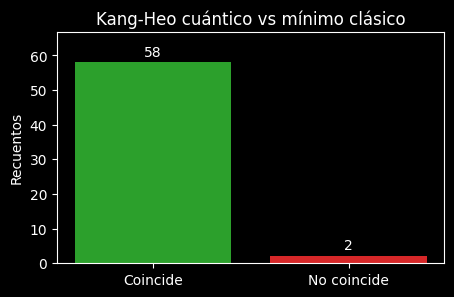

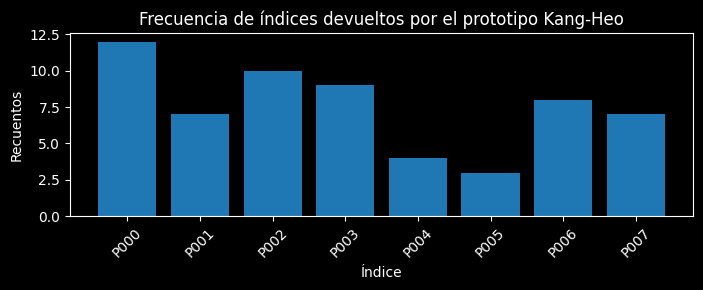

In [16]:
trial_hits = 0
trial_misses = 0
trial_quantum_indices = []
trial_classical_indices = []

for trial in range(TRIALS):
    trial_values = generate_values_with_unique_min(N_ITEMS, max_value=2**FIXED_BITS - 1, seed=100 + trial)
    trial_result = kang_heo_minimum_search(
        trial_values,
        shots=SHOTS_TRIALS,
        max_rounds=MAX_ROUNDS,
        tries_per_round=TRIES_PER_ROUND,
        seed=RANDOM_SEED + trial,
    )
    q_index = trial_result["best_index"]
    c_index = classical_min_index(trial_values)
    trial_quantum_indices.append(q_index)
    trial_classical_indices.append(c_index)
    if q_index == c_index:
        trial_hits += 1
    else:
        trial_misses += 1

success_rate = 100 * trial_hits / TRIALS
print(f"Ensayos: {TRIALS} | Aciertos: {trial_hits} | Fallos: {trial_misses} | Tasa de acierto: {success_rate:.1f}%")

plt.figure(figsize=(5, 3))
plt.bar(["Coincide", "No coincide"], [trial_hits, trial_misses], color=["tab:green", "tab:red"])
plt.title("Kang-Heo cuántico vs mínimo clásico")
plt.ylabel("Recuentos")
for label, value in zip(["Coincide", "No coincide"], [trial_hits, trial_misses]):
    plt.text(label, value + max(1, TRIALS * 0.01), str(value), ha="center", va="bottom")
plt.ylim(0, max(trial_hits, trial_misses) * 1.15 if TRIALS > 0 else 1)
plt.show()

plt.figure(figsize=(7, 3))
quantum_distribution = Counter(trial_quantum_indices)
plt.bar([pump_ids[i] for i in range(N_ITEMS)], [quantum_distribution.get(i, 0) for i in range(N_ITEMS)], color="tab:blue")
plt.title("Frecuencia de índices devueltos por el prototipo Kang-Heo")
plt.ylabel("Recuentos")
plt.xlabel("Índice")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Conclusiones

Este prototipo reproduce la lógica central del enfoque de Kang y Heo: la comparación cuántica se hace sobre un registro de valor cargado desde un registro de índice, y la mejora del umbral se obtiene iterando una búsqueda tipo Grover. La aproximación práctica aquí es usar una ROM controlada reversible en lugar de QRAM física y un marcado por patrones de valor menores que el umbral en vez de una síntesis exacta del comparador optimizado del paper.

Aun con esa simplificación, el objetivo sigue siendo el mismo que en Kang-Heo: encontrar mínimos cuánticamente de forma iterativa y comparar su desempeño frente al resultado clásico.

Creado con el modelo de IA LLM GPT-5.4